# NY Vir Keplerian Modeling
Demonstrates fitting two Keplerian orbits.

In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ['PYTENSOR_FLAGS'] = 'mode=NUMBA'

In [2]:
from ocpy.data import Data

data = Data.from_file("../ny_vir_minima.xlsx")
data = data.fill_errors(0.0001).calculate_weights()

t0 = 2453174.442769
period = 0.1010159690

oc = data.calculate_oc(
    reference_minimum=t0,
    reference_period=period,
    model_type="pymc"
)

<Axes: ylabel='O−C'>

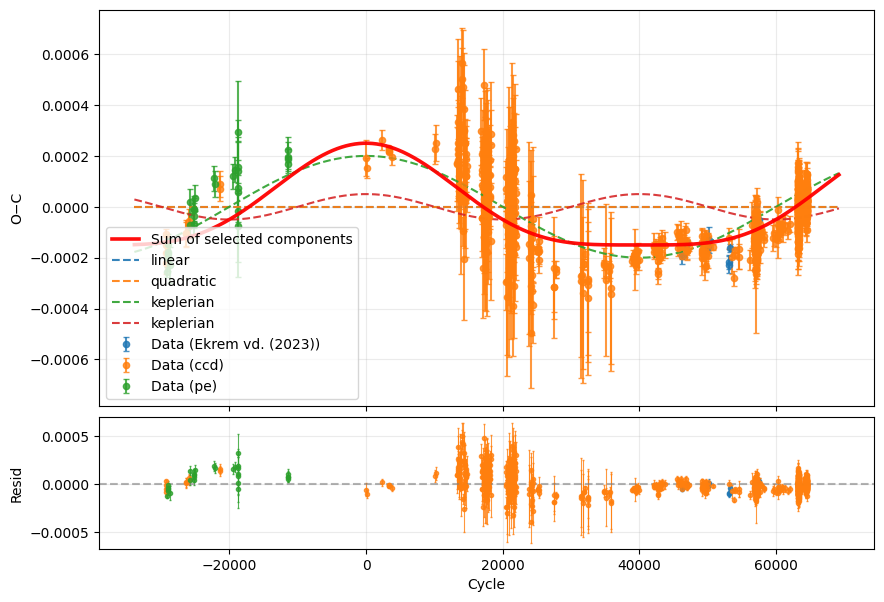

In [3]:
from ocpy.oc import Linear, Quadratic, Keplerian, Parameter

# 1) Linear (y = a*x + b)
lin = Linear(
    a=Parameter(value=0.0,   std=2e-5,  min=-1e-3,  max=1e-3,  fixed=False),
    b=Parameter(value=0.0,   std=2e-3,  min=-0.1,   max=0.1,   fixed=False),
)

# 2) Quadratic (q * x^2)
quad = Quadratic(
    q=Parameter(value=0.0,   std=5e-10, min=-1e-8,  max=1e-8,  fixed=False),
)

# 3) Keplerian component #1 (approx 80k epoch)
lite1 = Keplerian(
    P     = Parameter(value=80000,  std=8_000,  min=30_000,  max=150_000, fixed=False),
    T0    = Parameter(value=60000,  std=5_000,                          fixed=False),
    amp   = Parameter(value=2.0e-4, std=1.0e-4, min=0.0,    max=1.0e-3,  fixed=False),
    e     = Parameter(value=0.0,    fixed=True),
    omega = Parameter(value=0.0,    fixed=True),
)

# 4) Keplerian component #2 (approx 40k epoch)
lite2 = Keplerian(
    P     = Parameter(value=40000,  std=6_000,  min=10_000,  max=100_000, fixed=False),
    T0    = Parameter(value=30000,  std=5_000,                          fixed=False),
    amp   = Parameter(value=5.0e-5, std=2.5e-5, min=0.0,    max=5.0e-4,  fixed=False),
    e     = Parameter(value=0.0,    fixed=True),
    omega = Parameter(value=0.0,    fixed=True),
)

models = [lin, quad, lite1, lite2]

oc.plot(model=models)



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [linear_a, linear_b, quadratic_q, keplerian1_amp, keplerian1_P, keplerian1_T0, keplerian2_amp, keplerian2_P, keplerian2_T0]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 135 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


<Axes: ylabel='O−C'>

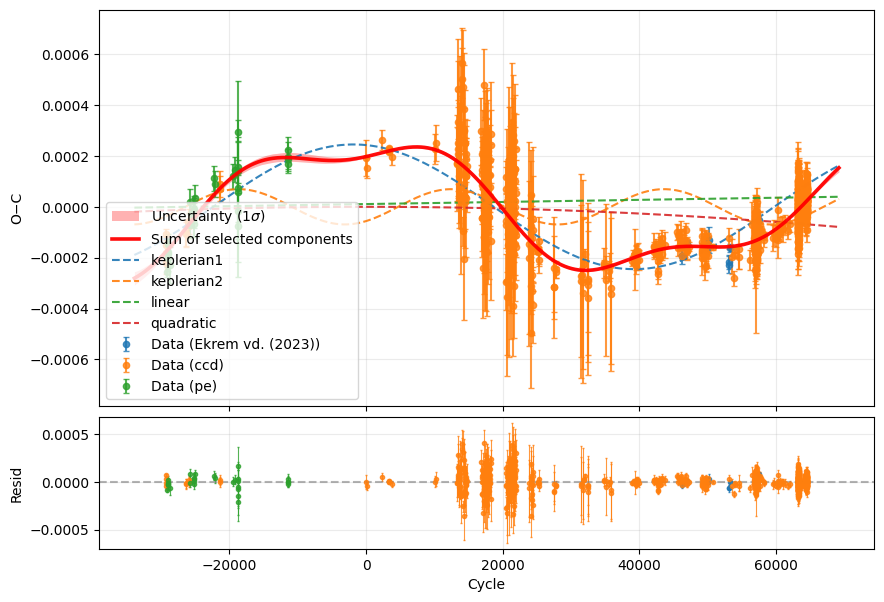

In [4]:
res = oc.fit(models, tune=1000, draws=1000, chains=2)
oc.plot(res)

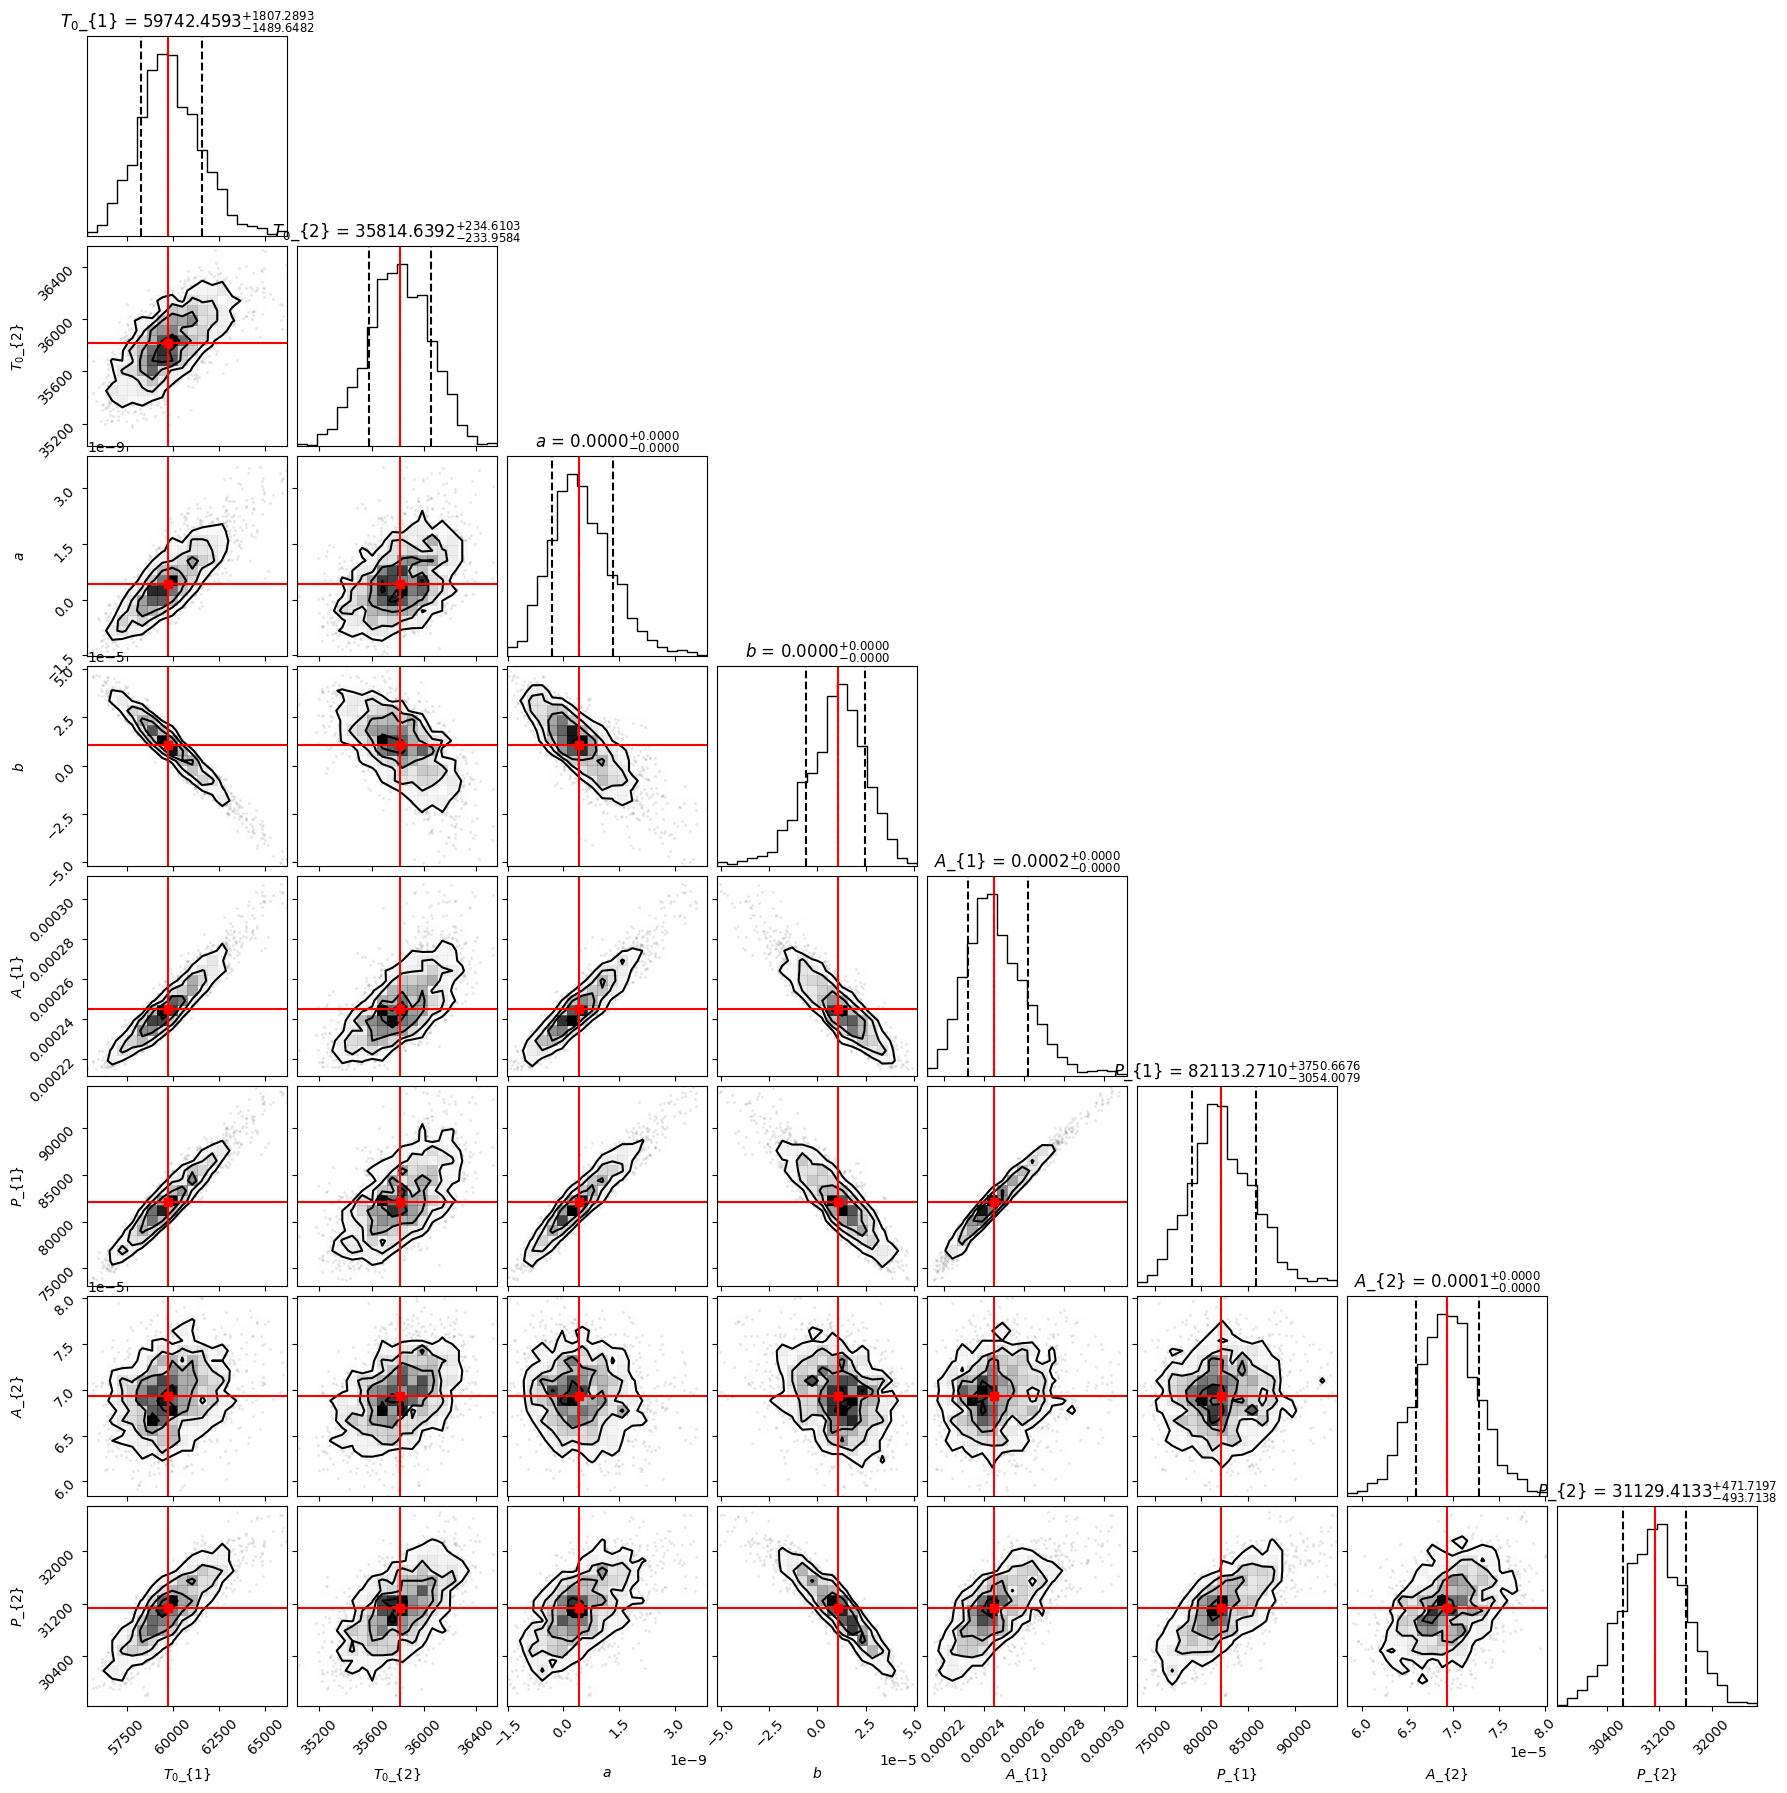

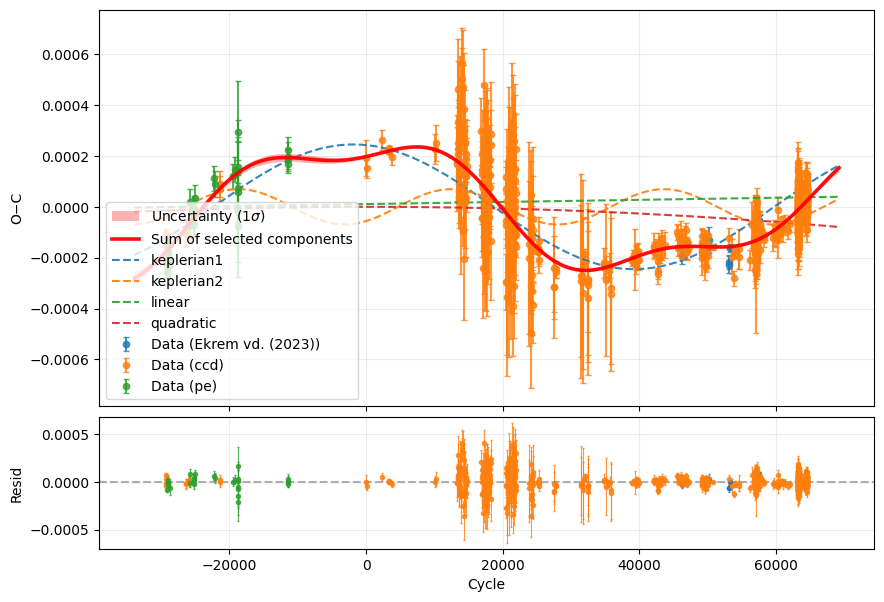

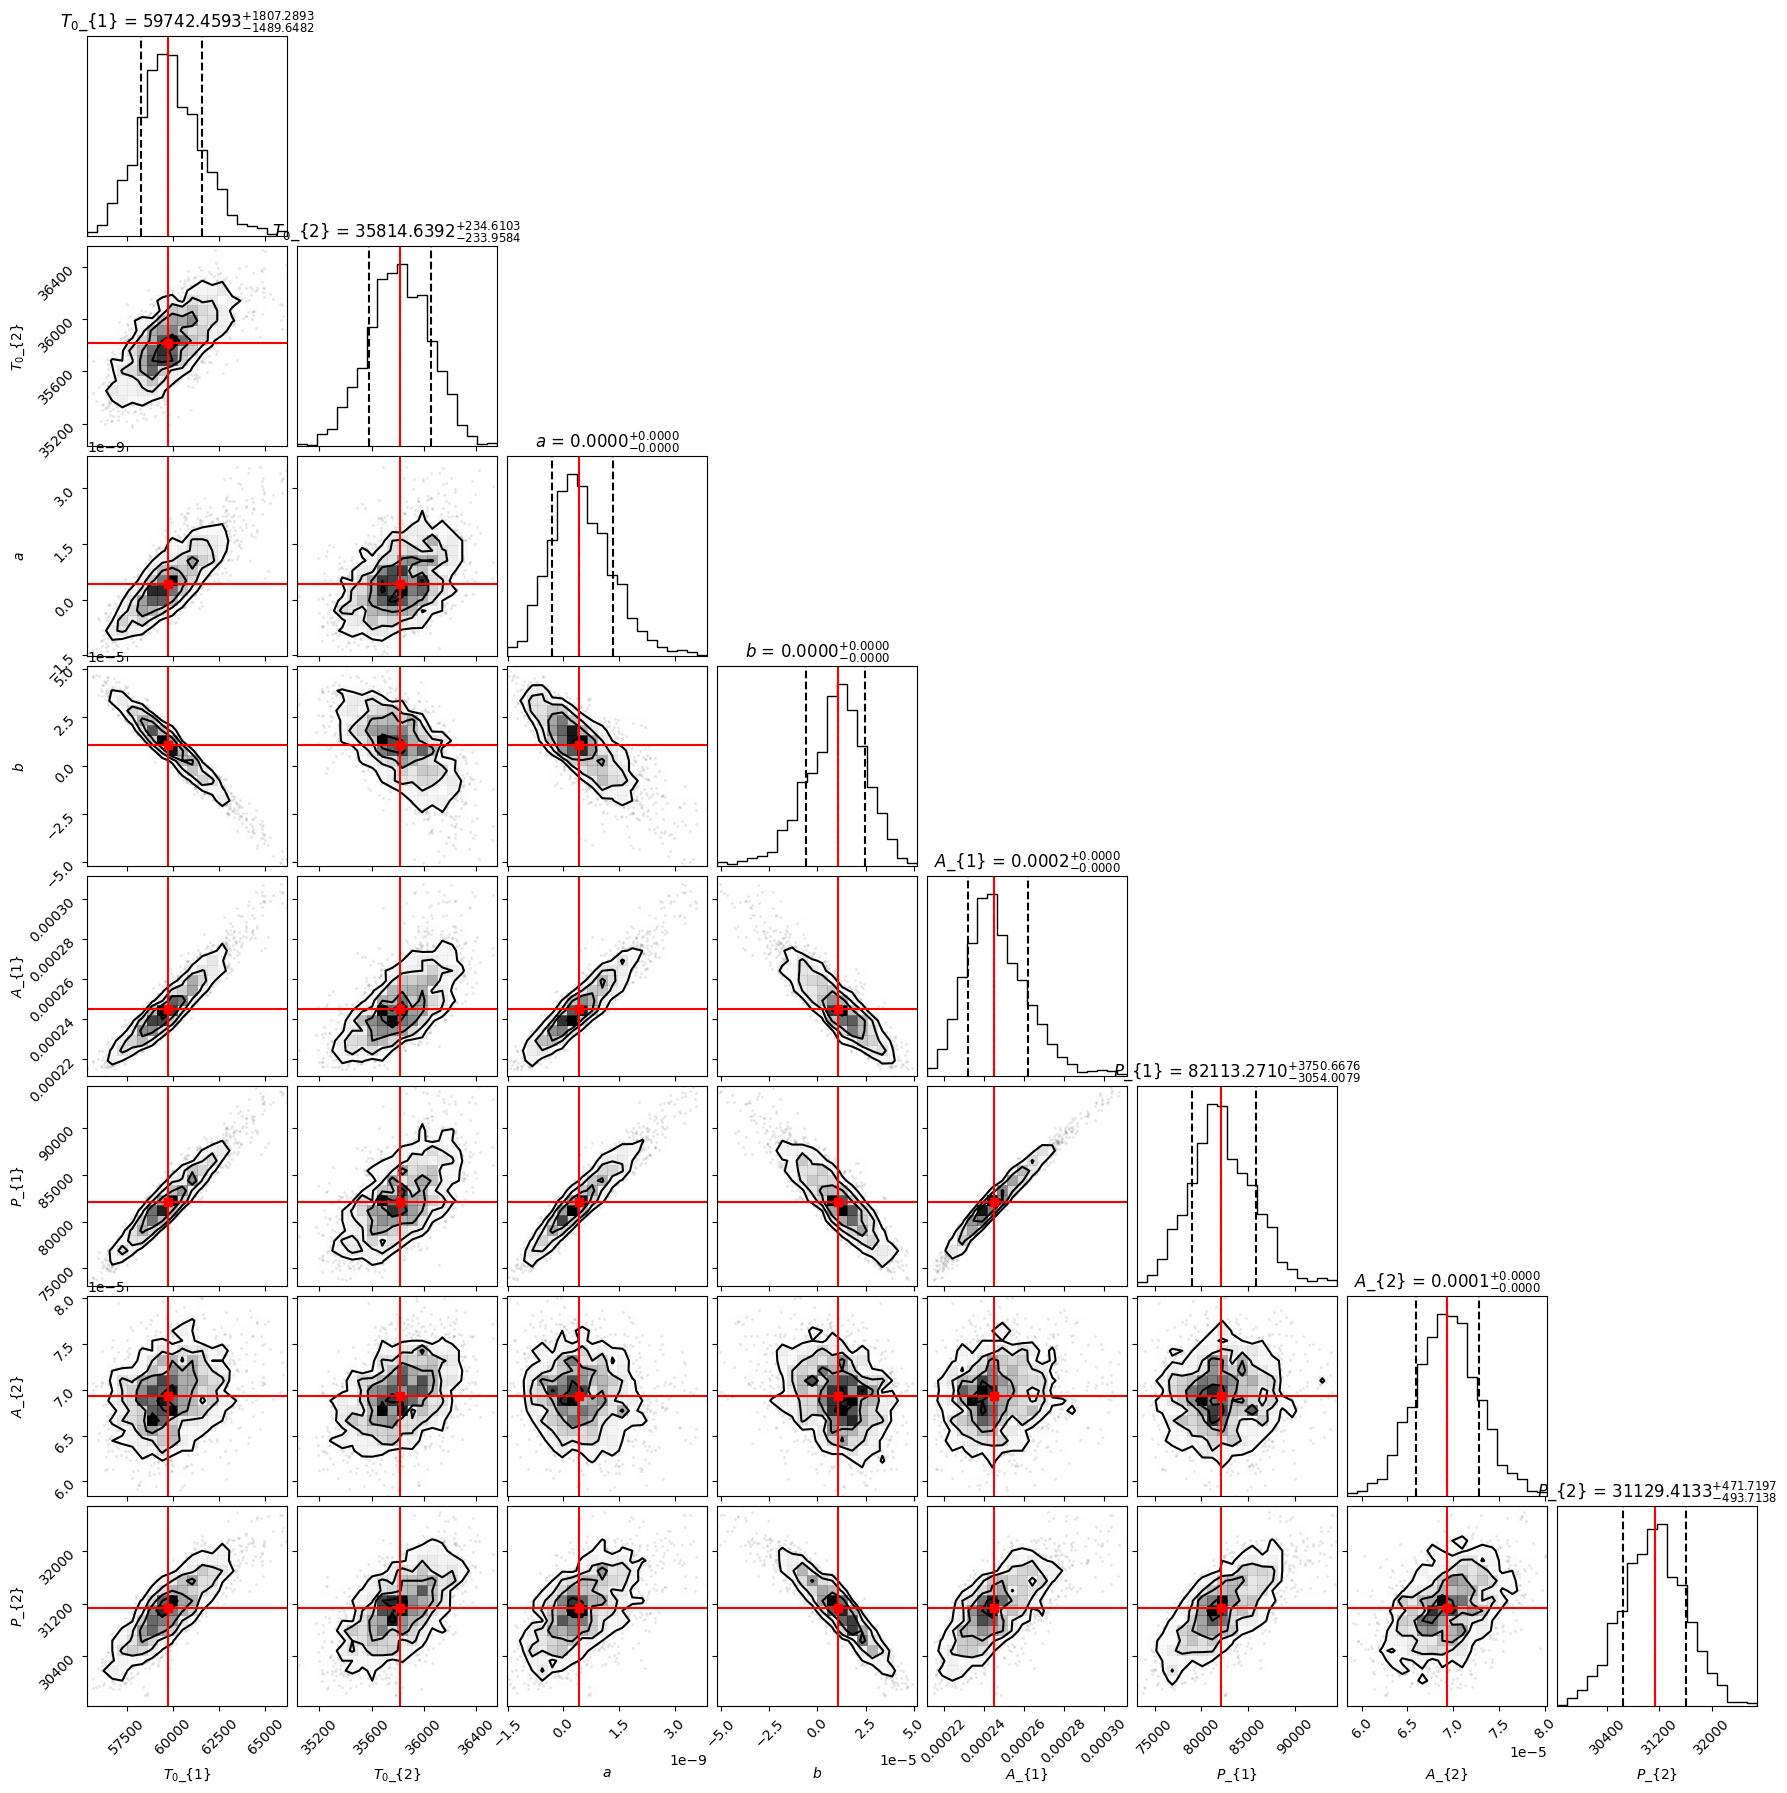

In [5]:
oc.plot(res)
oc.corner(res)